In [158]:

import os
import random
import requests
import warnings
from datetime import datetime
from datetime import datetime, timedelta

import holidays
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import itertools
from datetime import timedelta


# Suppress warnings
warnings.filterwarnings('ignore')

# Statistical and ML libraries
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif

# Time series specific libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy import stats 
# Scikit-learn utilities
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep learning libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

In [159]:
final_df = pd.read_csv(r'C:\Users\TPWODL\New folder_Content\DeepLearning_TimeSeries_LSTM_End_To_End\data\raw\twitter_complaint_data.csv')

In [160]:
final_df['time'] = pd.to_datetime(final_df['time'])

In [161]:
final_df

,time,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,complaint_count
0,2022-06-10,34.6,47,-0.433884,-0.900969,8.978045e-01,-0.440394,0.361714,-0.932289,10.0
1,2022-06-11,34.8,42,-0.974928,-0.222521,7.907757e-01,-0.612106,0.345612,-0.938377,12.0
2,2022-06-12,34.4,45,-0.781831,0.623490,6.513725e-01,-0.758758,0.329408,-0.944188,5.0
3,2022-06-13,34.7,45,0.000000,1.000000,4.853020e-01,-0.874347,0.313107,-0.949718,15.0
4,2022-06-14,32.9,52,0.781831,0.623490,2.993631e-01,-0.954139,0.296713,-0.954967,16.0
...,...,...,...,...,...,...,...,...,...,...
1237,2025-10-29,26.2,86,0.974928,-0.222521,-3.943559e-01,0.918958,-0.884068,0.467359,43.0
1238,2025-10-30,26.6,83,0.433884,-0.900969,-2.012985e-01,0.979530,-0.875892,0.482508,23.0
1239,2025-10-31,26.4,85,-0.433884,-0.900969,-2.449294e-16,1.000000,-0.867456,0.497513,26.0
1240,2025-11-01,26.8,84,-0.974928,-0.222521,2.012985e-01,0.979530,-0.858764,0.512371,27.0


In [162]:
final_df.set_index("time", inplace=True)

In [163]:
final_df

,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,complaint_count
time,,,,,,,,,
2022-06-10,34.6,47,-0.433884,-0.900969,8.978045e-01,-0.440394,0.361714,-0.932289,10.0
2022-06-11,34.8,42,-0.974928,-0.222521,7.907757e-01,-0.612106,0.345612,-0.938377,12.0
2022-06-12,34.4,45,-0.781831,0.623490,6.513725e-01,-0.758758,0.329408,-0.944188,5.0
2022-06-13,34.7,45,0.000000,1.000000,4.853020e-01,-0.874347,0.313107,-0.949718,15.0
2022-06-14,32.9,52,0.781831,0.623490,2.993631e-01,-0.954139,0.296713,-0.954967,16.0
...,...,...,...,...,...,...,...,...,...
2025-10-29,26.2,86,0.974928,-0.222521,-3.943559e-01,0.918958,-0.884068,0.467359,43.0
2025-10-30,26.6,83,0.433884,-0.900969,-2.012985e-01,0.979530,-0.875892,0.482508,23.0
2025-10-31,26.4,85,-0.433884,-0.900969,-2.449294e-16,1.000000,-0.867456,0.497513,26.0


Manual Outlier Cutoffs → Lower: 0, Upper: 80
Original Shape: (1242, 9)
Filtered Shape: (1207, 9)


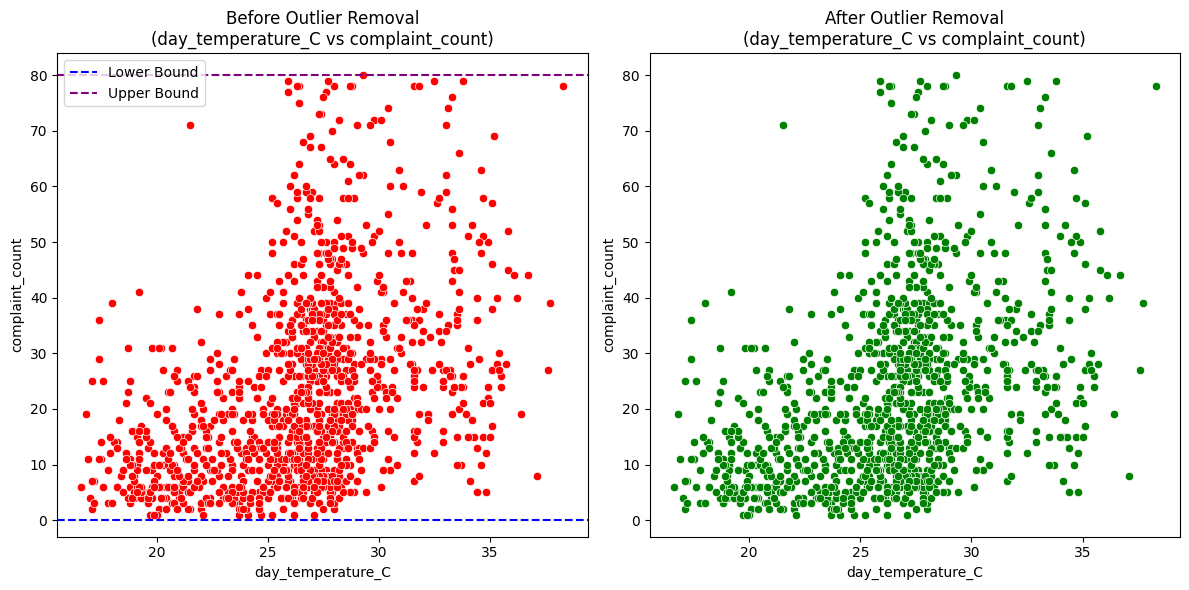

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Define your columns ---
target_col = 'complaint_count'        # 🔁 your target column
X_feature = 'day_temperature_C'    # 🔁 your x-axis feature (e.g., 'humidity', 'day', etc.)

# --- Step 2: Define manual cutoff values ---
lowerbound = 0     # 👈 set your lower limit
upperbound = 80    # 👈 set your upper limit

# --- Step 3: Apply filtering based on manual cutoffs ---
df = final_df[(final_df[target_col] >= lowerbound) & (final_df[target_col] <= upperbound)]

print(f"Manual Outlier Cutoffs → Lower: {lowerbound}, Upper: {upperbound}")
print("Original Shape:", final_df.shape)
print("Filtered Shape:", df.shape)

# --- Step 4: Scatter Plot Visualization ---
plt.figure(figsize=(12, 6))

# Before outlier removal
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x=X_feature, y=target_col, color='red', alpha=1)
plt.axhline(lowerbound, color='blue', linestyle='--', label='Lower Bound')
plt.axhline(upperbound, color='purple', linestyle='--', label='Upper Bound')
plt.legend()
plt.title(f"Before Outlier Removal\n({X_feature} vs {target_col})")

# After outlier removal
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x=X_feature, y=target_col, color='green', alpha=1)
plt.title(f"After Outlier Removal\n({X_feature} vs {target_col})")

plt.tight_layout()
plt.show()

In [165]:
df

,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,complaint_count
time,,,,,,,,,
2022-06-10,34.6,47,-0.433884,-0.900969,8.978045e-01,-0.440394,0.361714,-0.932289,10.0
2022-06-11,34.8,42,-0.974928,-0.222521,7.907757e-01,-0.612106,0.345612,-0.938377,12.0
2022-06-12,34.4,45,-0.781831,0.623490,6.513725e-01,-0.758758,0.329408,-0.944188,5.0
2022-06-13,34.7,45,0.000000,1.000000,4.853020e-01,-0.874347,0.313107,-0.949718,15.0
2022-06-14,32.9,52,0.781831,0.623490,2.993631e-01,-0.954139,0.296713,-0.954967,16.0
...,...,...,...,...,...,...,...,...,...
2025-10-29,26.2,86,0.974928,-0.222521,-3.943559e-01,0.918958,-0.884068,0.467359,43.0
2025-10-30,26.6,83,0.433884,-0.900969,-2.012985e-01,0.979530,-0.875892,0.482508,23.0
2025-10-31,26.4,85,-0.433884,-0.900969,-2.449294e-16,1.000000,-0.867456,0.497513,26.0


In [166]:
# Separate features (X) and target (y)
X = df.drop(columns=['complaint_count'])
y = df['complaint_count']


In [167]:
# Combine X and y for synchronized scaling
data = X.copy()
data['complaint_count'] = y.values

In [168]:
# Initialize scalers with range (0, 1)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
# Fit and transform
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

In [169]:
# Create sequences for LSTM
def create_sequences(X, y, seq_length=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

In [170]:
seq_length = 7  # Lookback window
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)

In [171]:
X_seq[0]

array([[8.29493088e-01, 3.23943662e-01, 2.77479066e-01, 0.00000000e+00,
        9.49479173e-01, 2.77950623e-01, 6.80858540e-01, 3.38374997e-02],
       [8.38709677e-01, 2.53521127e-01, 0.00000000e+00, 3.56895868e-01,
        8.95895998e-01, 1.91873892e-01, 6.72807757e-01, 3.07933540e-02],
       [8.20276498e-01, 2.95774648e-01, 9.90311321e-02, 8.01937736e-01,
        8.26104795e-01, 1.18359232e-01, 6.64705766e-01, 2.78882416e-02],
       [8.34101382e-01, 2.95774648e-01, 5.00000000e-01, 1.00000000e+00,
        7.42962822e-01, 6.04163420e-02, 6.56554970e-01, 2.51230235e-02],
       [7.51152074e-01, 3.94366197e-01, 9.00968868e-01, 8.01937736e-01,
        6.49873924e-01, 2.04174111e-02, 6.48357783e-01, 2.24985188e-02],
       [6.49769585e-01, 5.91549296e-01, 1.00000000e+00, 3.56895868e-01,
        5.50649169e-01, 5.55111512e-17, 6.40116635e-01, 2.00155054e-02],
       [6.35944700e-01, 6.19718310e-01, 7.22520934e-01, 5.55111512e-17,
        4.49350831e-01, 0.00000000e+00, 6.31833967e-01, 1.

In [172]:
y_seq[0]

np.float64(0.15189873417721517)

In [173]:
print(f"Sequence shape: X={X_seq.shape}, y={y_seq.shape}")


Sequence shape: X=(1200, 7, 8), y=(1200,)


In [174]:
# Train-test split (80-20)
split_idx = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (960, 7, 8), Test set: (240, 7, 8)


In [177]:
model = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(seq_length, X_train.shape[2])),
    Dropout(0.2),
    
    LSTM(units=32, return_sequences=True),
    Dropout(0.2),
    
    LSTM(units=16, return_sequences=False),
    Dropout(0.2),
    
    Dense(units=8, activation='relu'),
    Dense(units=1, activation='sigmoid')  # corrected 'sigmoide' to 'sigmoid'
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 7, 64)          │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_24 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,385 (134.32 KB)

 Trainable params: 34,385 (134.32 KB)

 Non-trainable params: 0 (0.00 B)

In [178]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=80, restore_best_weights=True)

In [179]:
# Train model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"\nTraining completed at epoch {len(history.history['loss'])}")



Training completed at epoch 81


In [180]:
# 3. MAKE PREDICTIONS

y_train_pred_scaled = model.predict(X_train, verbose=0)
y_test_pred_scaled = model.predict(X_test, verbose=0)


In [181]:
# Inverse transform to original scale
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled).flatten()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled).flatten()
y_train_actual = scaler_y.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [183]:
# 4. EVALUATION METRICS

def evaluate_model(y_true, y_pred, set_name=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{set_name} Metrics:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.4f}%")
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}


In [184]:
train_metrics = evaluate_model(y_train_actual, y_train_pred, "TRAINING SET")
test_metrics = evaluate_model(y_test_actual, y_test_pred, "TEST SET")


TRAINING SET Metrics:
  MSE:  255.7516
  RMSE: 15.9922
  MAE:  13.5848
  R²:   -0.3116
  MAPE: 192.8652%

TEST SET Metrics:
  MSE:  510.2869
  RMSE: 22.5895
  MAE:  17.5919
  R²:   -0.5258
  MAPE: 44.8212%


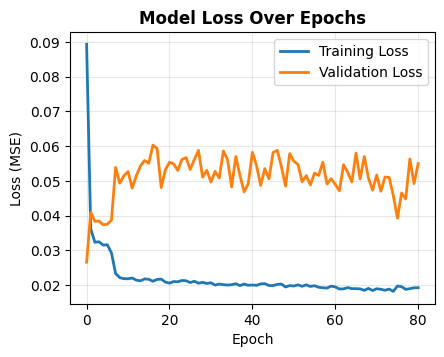

In [185]:
# 5. VISUALIZATIONS - MODEL PERFORMANCE

fig = plt.figure(figsize=(16, 12))

# 1. Training History - Loss
ax1 = plt.subplot(3, 3, 1)
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Model Loss Over Epochs', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)


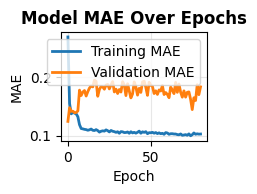

In [186]:
# 2. Training History - MAE
ax2 = plt.subplot(3, 3, 2)
ax2.plot(history.history['mae'], label='Training MAE', linewidth=2)
ax2.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.set_title('Model MAE Over Epochs', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

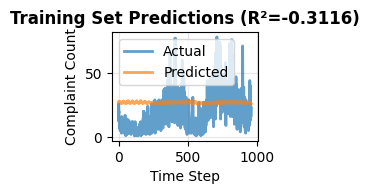

In [188]:
# 3. Predictions vs Actual - Training Set
ax3 = plt.subplot(3, 3, 3)
ax3.plot(y_train_actual, label='Actual', linewidth=2, alpha=0.7)
ax3.plot(y_train_pred, label='Predicted', linewidth=2, alpha=0.7)
ax3.set_xlabel('Time Step')
ax3.set_ylabel('Complaint Count')
ax3.set_title(f'Training Set Predictions (R²={train_metrics["R2"]:.4f})', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)


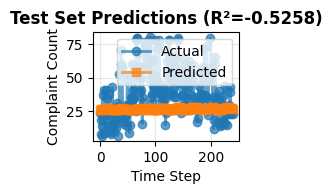

In [189]:
ax4 = plt.subplot(3, 3, 4)
ax4.plot(y_test_actual, label='Actual', linewidth=2, alpha=0.7, marker='o')
ax4.plot(y_test_pred, label='Predicted', linewidth=2, alpha=0.7, marker='s')
ax4.set_xlabel('Time Step')
ax4.set_ylabel('Complaint Count')
ax4.set_title(f'Test Set Predictions (R²={test_metrics["R2"]:.4f})', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

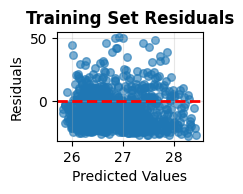

In [190]:
# 5. Residuals - Training Set
ax5 = plt.subplot(3, 3, 5)
residuals_train = y_train_actual - y_train_pred
ax5.scatter(y_train_pred, residuals_train, alpha=0.6, s=30)
ax5.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax5.set_xlabel('Predicted Values')
ax5.set_ylabel('Residuals')
ax5.set_title('Training Set Residuals', fontweight='bold')
ax5.grid(True, alpha=0.3)


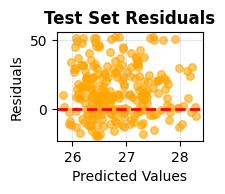

In [191]:
# 6. Residuals - Test Set
ax6 = plt.subplot(3, 3, 6)
residuals_test = y_test_actual - y_test_pred
ax6.scatter(y_test_pred, residuals_test, alpha=0.6, s=30, color='orange')
ax6.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax6.set_xlabel('Predicted Values')
ax6.set_ylabel('Residuals')
ax6.set_title('Test Set Residuals', fontweight='bold')
ax6.grid(True, alpha=0.3)


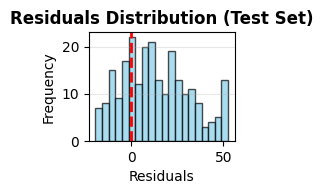

In [192]:
# 7. Residuals Distribution - Test Set
ax7 = plt.subplot(3, 3, 7)
ax7.hist(residuals_test, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
ax7.set_xlabel('Residuals')
ax7.set_ylabel('Frequency')
ax7.set_title('Residuals Distribution (Test Set)', fontweight='bold')
ax7.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax7.grid(True, alpha=0.3, axis='y')

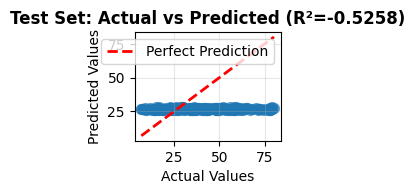

In [193]:
# 8. Actual vs Predicted Scatter - Test Set
ax8 = plt.subplot(3, 3, 8)
ax8.scatter(y_test_actual, y_test_pred, alpha=0.6, s=50)
min_val = min(y_test_actual.min(), y_test_pred.min())
max_val = max(y_test_actual.max(), y_test_pred.max())
ax8.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax8.set_xlabel('Actual Values')
ax8.set_ylabel('Predicted Values')
ax8.set_title(f'Test Set: Actual vs Predicted (R²={test_metrics["R2"]:.4f})', fontweight='bold')
ax8.legend()
ax8.grid(True, alpha=0.3)

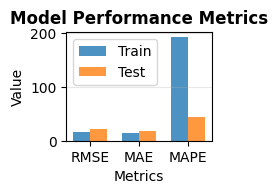

In [194]:
# 9. Metrics Comparison
ax9 = plt.subplot(3, 3, 9)
metrics_names = ['RMSE', 'MAE', 'MAPE']
train_vals = [train_metrics['RMSE'], train_metrics['MAE'], train_metrics['MAPE']]
test_vals = [test_metrics['RMSE'], test_metrics['MAE'], test_metrics['MAPE']]
x = np.arange(len(metrics_names))
width = 0.35
ax9.bar(x - width/2, train_vals, width, label='Train', alpha=0.8)
ax9.bar(x + width/2, test_vals, width, label='Test', alpha=0.8)
ax9.set_xlabel('Metrics')
ax9.set_ylabel('Value')
ax9.set_title('Model Performance Metrics', fontweight='bold')
ax9.set_xticks(x)
ax9.set_xticklabels(metrics_names)
ax9.legend()
ax9.grid(True, alpha=0.3, axis='y')